# Датасет CelebA - Original Wild Images

## Скачивание

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

Я работаю с датасетом CelebA - Original Wild Images.

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!mkdir -p /content/celeba
!kaggle datasets download -d kevinpatel04/celeba-original-wild-images -p /content/celeba --unzip

Dataset URL: https://www.kaggle.com/datasets/kevinpatel04/celeba-original-wild-images
License(s): DbCL-1.0
100% 17.3G/17.3G [04:17<00:00, 72.1MB/s]



In [ ]:
!find /content/celeba -iname "*identity*" -o -iname "*landmark*" -o -iname "*bbox*" -o -iname "*attr*"

/content/celeba/list_bbox_celeba.csv
/content/celeba/list_attr_celeba.csv
/content/celeba/list_landmarks_align_celeba.csv
/content/celeba/list_landmarks_celeba.txt
/content/celeba/identity_CelebA.txt


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/celeba")

In [ ]:
ATTR_PATH = PROJECT_DIR / "list_attr_celeba.csv"
BBOX_PATH = PROJECT_DIR / "list_bbox_celeba.csv"
LANDMARKS_PATH = PROJECT_DIR / "list_landmarks_celeba.txt"
IDENTITY_PATH = PROJECT_DIR / "identity_CelebA.txt"

OUT_DIR = PROJECT_DIR / "prepared_data"
CROPS_DIR = OUT_DIR / "cropped_faces"
ALIGNED_DIR = OUT_DIR / "aligned_faces"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CROPS_DIR.mkdir(parents=True, exist_ok=True)
ALIGNED_DIR.mkdir(parents=True, exist_ok=True)

Читаю файлы:

In [ ]:
attr_df = pd.read_csv(ATTR_PATH)

In [ ]:
attr_df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [ ]:
bbox_df = pd.read_csv(BBOX_PATH)

In [ ]:
bbox_df.head()

,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


Это landmarks для невыровненных фотографий:

In [ ]:
landmarks_df = pd.read_csv(LANDMARKS_PATH, sep=r"\s+", skiprows=1)

landmarks_df = landmarks_df.reset_index().rename(columns={"index": "image_id"})

In [ ]:
landmarks_df.head()

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,165,184,244,176,196,249,194,271,266,260
1,000002.jpg,140,204,220,204,168,254,146,289,226,289
2,000003.jpg,244,104,264,105,263,121,235,134,251,140
3,000004.jpg,796,539,984,539,930,687,762,756,915,756
4,000005.jpg,273,169,328,161,298,172,283,208,323,207


In [ ]:
identity_df = pd.read_csv(IDENTITY_PATH, sep=r"\s+", header=None, names=["identity_id"])

identity_df = identity_df.reset_index().rename(columns={"index": "image_id"})

In [ ]:
identity_df.head()

,image_id,identity_id
0,000001.jpg,2880
1,000002.jpg,2937
2,000003.jpg,8692
3,000004.jpg,5805
4,000005.jpg,9295


In [ ]:
df = attr_df.merge(bbox_df, on="image_id", how="inner")
df = df.merge(landmarks_df, on="image_id", how="inner")
df = df.merge(identity_df, on="image_id", how="inner")

In [ ]:
image_paths = {}

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    for path in PROJECT_DIR.rglob(ext):
        image_paths[path.name] = path

In [ ]:
df["image_path"] = df["image_id"].map(image_paths)

In [ ]:
df.columns

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'x_1', 'y_1', 'width', 'height',
       'lefteye_x', 'lefteye_y', 'righteye_x', 'righteye_y', 'nose_x',
       'nose_y', 'leftmouth_x', 'leftmouth_y', 'rightmouth_x', 'rightmouth_y',
       'identity_id', 'image_path'],
      dtype='object')

## Подготовка датасета

Убираю замыленные фотографии:

In [ ]:
filtered_df = df.copy()

In [ ]:
filtered_df = filtered_df[filtered_df["Blurry"] == -1]

# еще я удалила фото со шляпами
filtered_df = filtered_df[filtered_df["Wearing_Hat"] == -1]

In [ ]:
len(filtered_df)

183125

Беру 500 людей у кого больше всего фото

In [ ]:
identity_counts = filtered_df.groupby("identity_id").size().sort_values(ascending=False).reset_index(name="counts")
identity_counts.head()

,identity_id,counts
0,3782,35
1,3745,33
2,2820,33
3,8968,32
4,3227,32


In [ ]:
identity_counts = identity_counts[:500]

In [ ]:
identity_counts.describe()

,identity_id,counts
count,500.000000,500.000000
mean,5215.820000,30.034000
std,2729.755927,0.324121
min,21.000000,30.000000
25%,2882.250000,30.000000
50%,5293.000000,30.000000
75%,7122.000000,30.000000
max,10167.000000,35.000000


In [ ]:
identity_counts.shape

(500, 2)

In [ ]:
chosen_identity_id = identity_counts["identity_id"]

filtered_df = filtered_df[filtered_df["identity_id"].isin(chosen_identity_id)].copy()

In [ ]:
print(filtered_df.shape)

(15017, 57)


In [ ]:
df = filtered_df.copy()

Вся информация о датасете:

In [ ]:
print(df.shape)
print("Число людей:", df["identity_id"].nunique())
print(df["identity_id"].value_counts().describe())

(15017, 57)
Число людей: 500
count    500.000000
mean      30.034000
std        0.324121
min       30.000000
25%       30.000000
50%       30.000000
75%       30.000000
max       35.000000
Name: count, dtype: float64


## Crop

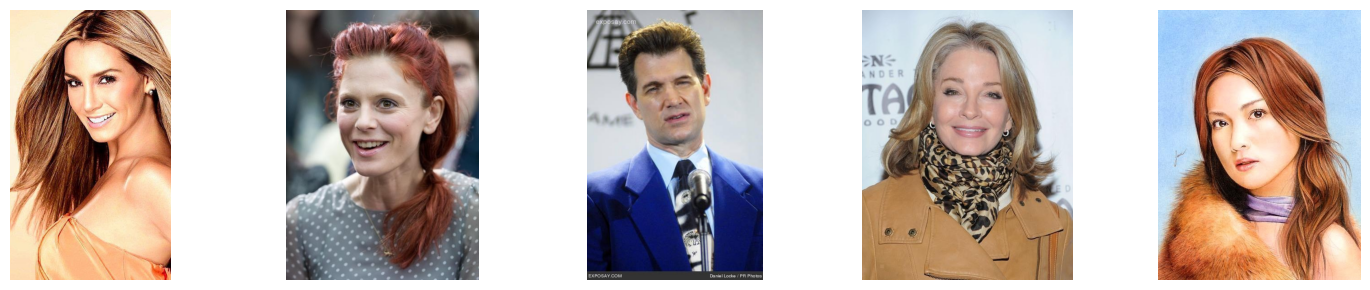

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    row = df.iloc[i]
    img = Image.open(row["image_path"]).convert("RGB")
    img = np.array(img)

    axs[i].imshow(img)
    axs[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
from PIL import Image
import numpy as np
from tqdm import tqdm

In [ ]:
landmark_cols = [
    "lefteye_x", "lefteye_y",
    "righteye_x", "righteye_y",
    "nose_x", "nose_y",
    "leftmouth_x", "leftmouth_y",
    "rightmouth_x", "rightmouth_y"
]

In [ ]:
def crop_and_resize_face(row, crop_size=128, margin=0.0):
    # row - строка из таблицы
    # margin - отступ около bbox
    img = Image.open(row["image_path"]).convert("RGB")
    img = np.array(img)

    img_h, img_w = img.shape[:2]

    x, y, w, h = int(row["x_1"]), int(row["y_1"]), int(row["width"]), int(row["height"])

    dx = int(w * margin)
    dy = int(h * margin)

    x1 = max(0, x - dx)
    y1 = max(0, y - dy)
    x2 = min(img_w, x + w + dx)
    y2 = min(img_h, y + h + dy)

    crop = img[y1:y2, x1:x2]

    old_h, old_w = crop.shape[:2]

    if old_h == 0 or old_w == 0:
        return None, None

    crop_resized = cv2.resize(crop, (crop_size, crop_size))

    # landmarks пересчитываю
    points = np.array([
        [row["lefteye_x"], row["lefteye_y"]],
        [row["righteye_x"], row["righteye_y"]],
        [row["nose_x"], row["nose_y"]],
        [row["leftmouth_x"], row["leftmouth_y"]],
        [row["rightmouth_x"], row["rightmouth_y"]],
    ], dtype=np.float32)

    points[:, 0] = (points[:, 0] - x1) * crop_size / old_w
    points[:, 1] = (points[:, 1] - y1) * crop_size / old_h

    return crop_resized, points

In [ ]:
processed_rows = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    crop_img, points = crop_and_resize_face(row, crop_size=128)

    if crop_img is None:
        continue

    save_name = row["image_id"]
    save_path = CROPS_DIR / save_name

    Image.fromarray(crop_img).save(save_path)

    new_row = row.copy()
    new_row["crop_path"] = str(save_path)

    new_row["lefteye_x_crop"] = points[0, 0]
    new_row["lefteye_y_crop"] = points[0, 1]

    new_row["righteye_x_crop"] = points[1, 0]
    new_row["righteye_y_crop"] = points[1, 1]

    new_row["nose_x_crop"] = points[2, 0]
    new_row["nose_y_crop"] = points[2, 1]

    new_row["leftmouth_x_crop"] = points[3, 0]
    new_row["leftmouth_y_crop"] = points[3, 1]

    new_row["rightmouth_x_crop"] = points[4, 0]
    new_row["rightmouth_y_crop"] = points[4, 1]

    processed_rows.append(new_row)

processed_df = pd.DataFrame(processed_rows).reset_index(drop=True)

processed_df.to_csv(OUT_DIR / "processed_10000_faces.csv", index=False)

processed_df.shape

100%|██████████| 15017/15017 [04:01<00:00, 62.18it/s]


(15017, 68)

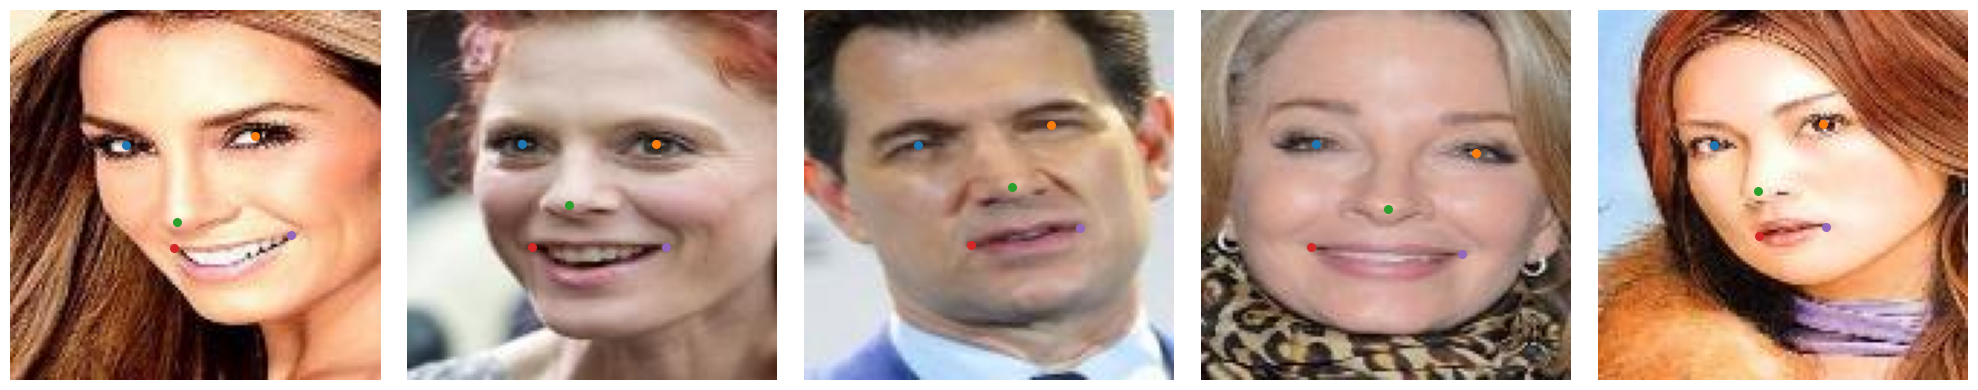

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    row = processed_df.iloc[i]

    img = Image.open(row["crop_path"]).convert("RGB")
    img = np.array(img)

    points = np.array([
        [row["lefteye_x_crop"], row["lefteye_y_crop"]],
        [row["righteye_x_crop"], row["righteye_y_crop"]],
        [row["nose_x_crop"], row["nose_y_crop"]],
        [row["leftmouth_x_crop"], row["leftmouth_y_crop"]],
        [row["rightmouth_x_crop"], row["rightmouth_y_crop"]],
    ])

    ax = axs[i]
    ax.imshow(img)

    for x, y in points:
        ax.scatter(x, y, s=30)

    ax.axis("off")

plt.tight_layout()
plt.show()


# train_test_split


In [ ]:
from sklearn.model_selection import train_test_split
import torch

In [ ]:
train_df, val_df = train_test_split(
    processed_df,
    test_size=0.1,
    random_state=42,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(train_df.shape, val_df.shape)

(13515, 68) (1502, 68)


# Heatmap-таргеты для landmarks

С помощью heatmaps я представляю координату landmark не одной точкой, а пятном, которое задается гауссианом.

In [ ]:
def make_heatmaps(points, image_size=128, heatmap_size=64, sigma=2.0):
    """
    points: координаты точек landmarks на изображении image_size x image_size.
    return: torch.Tensor shape [5, heatmap_size, heatmap_size]
    """
    points = np.asarray(points, dtype=np.float32).copy()
    points = points * (heatmap_size / image_size) # координаты перемасштабирую

    # y координаты и x координаты пикселей
    yy, xx = torch.meshgrid(
        torch.arange(heatmap_size, dtype=torch.float32),
        torch.arange(heatmap_size, dtype=torch.float32),
        indexing="ij",
    )

    heatmaps = []
    for x, y in points:
        # гауссиан
        hm = torch.exp(-((xx - x) ** 2 + (yy - y) ** 2) / (2 * sigma ** 2))
        heatmaps.append(hm)

    return torch.stack(heatmaps, dim=0)

In [ ]:
# ряд из prossesed_df преобразую в матрицу с координатами landmarks
def row_to_points(row, suffix="_crop"):
    return np.array([
        [row[f"lefteye_x{suffix}"], row[f"lefteye_y{suffix}"]],
        [row[f"righteye_x{suffix}"], row[f"righteye_y{suffix}"]],
        [row[f"nose_x{suffix}"], row[f"nose_y{suffix}"]],
        [row[f"leftmouth_x{suffix}"], row[f"leftmouth_y{suffix}"]],
        [row[f"rightmouth_x{suffix}"], row[f"rightmouth_y{suffix}"]],
    ], dtype=np.float32)

Пример:

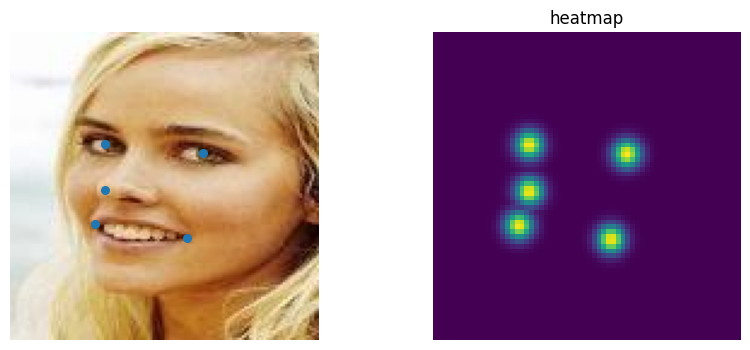

In [ ]:
row = train_df.iloc[0]
img = Image.open(row["crop_path"]).convert("RGB")
points = row_to_points(row)

heatmaps = make_heatmaps(points)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.scatter(points[:, 0], points[:, 1], s=30)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(heatmaps.max(dim=0).values.numpy())
plt.axis("off")
plt.title("heatmap")
plt.show()

# Dataset и Dataloader

In [ ]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
class FaceLandmarksDataset(Dataset):
    def __init__(self, df, image_size=128, heatmap_size=64, sigma=2.0):
        self.df = df.reset_index(drop=True)
        self.image_size = image_size
        self.heatmap_size = heatmap_size
        self.sigma = sigma

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["crop_path"]).convert("RGB")
        img = img.resize((self.image_size, self.image_size))
        img = np.array(img).astype(np.float32) / 255.0

        # [H, W, C] -> [C, H, W]
        img = torch.tensor(img).permute(2, 0, 1)

        # нормализация в диапазон примерно [-1, 1]
        img = (img - 0.5) / 0.5

        points = row_to_points(row)
        heatmaps = make_heatmaps(points, image_size=self.image_size, heatmap_size=self.heatmap_size, sigma=self.sigma)

        points = torch.tensor(points, dtype=torch.float32)

        return img, heatmaps, points

In [ ]:
batch_size = 64

train_dataset = FaceLandmarksDataset(train_df, image_size=128, heatmap_size=64, sigma=2.0)
val_dataset = FaceLandmarksDataset(val_df, image_size=128, heatmap_size=64, sigma=2.0)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

imgs, heatmaps, points = next(iter(train_loader))
imgs.shape, heatmaps.shape, points.shape

(torch.Size([64, 3, 128, 128]),
 torch.Size([64, 5, 64, 64]),
 torch.Size([64, 5, 2]))

# Stacked Hourglass Network

В разных вариантах пайплайна для распознавания лиц ключевые точки лица могут предсказываться сразу детектором (MTCNN, RetinaFace и прочие), а могут и отдельной моделью. В этом проекте рассматривается второй вариант. То есть, за детекцию ключевых точек будет отвечать отдельная модель.

**Hourglass** — это U-Net-подобная структура, которая сначала уменьшает разрешение изображения, затем восстанавливает его обратно. Такая структура напоминает по форме песочные часы (hourglass).

**Stacked Hourglass Network** состоит Hourglass-блоков, каждый из которых старается уточнять результат предыдущего. Несмотря на то, что она придумана в 2016 году, до сих пор используется во многих исследовательских проектах для задачи обнаружения ключевых точек.

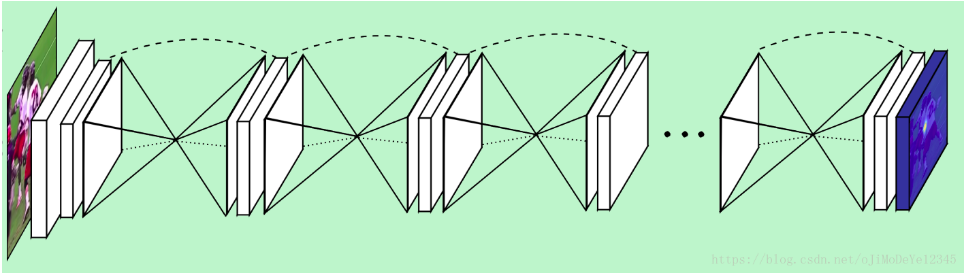

## Hourglass

Структура Hourglass блока:

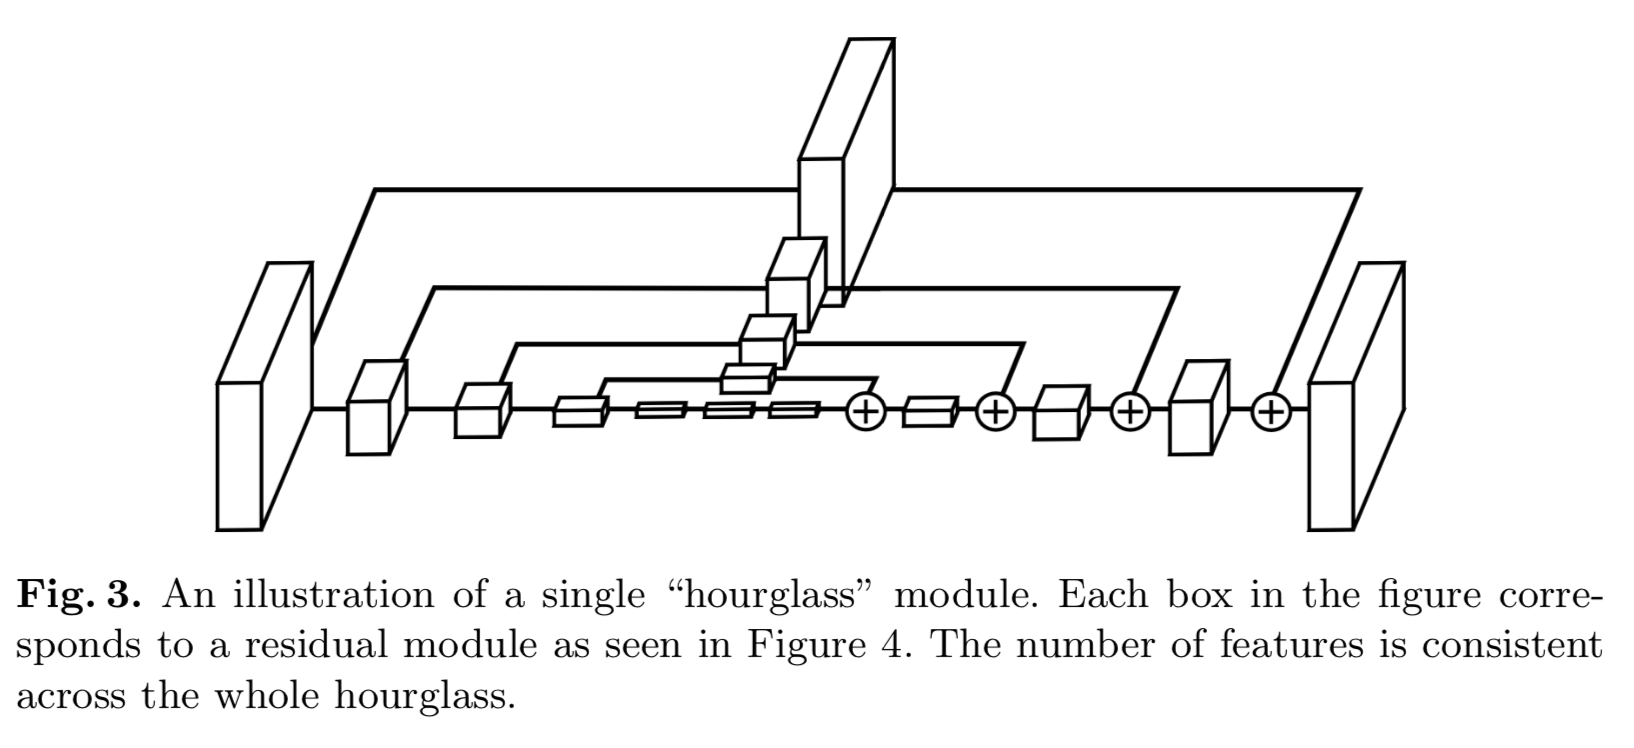

Каждый бокс в этой схеме - это Residual block, который отвечает за извлечение признаков на разных уровнях детализации (вспоминаем про ResNet). Причем, каждый такой блок имеет одинаковую размерность на входе и на выходе.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.skip = (nn.Identity() if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1))

        mid_channels = out_channels // 2

        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(mid_channels, mid_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(mid_channels, out_channels, kernel_size=1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))

        return self.relu(x + residual)

In [ ]:
class HourglassBlock(nn.Module):
    def __init__(self, depth, num_features):
        super().__init__()
        self.depth = depth

        self.up1 = ResidualBlock(num_features, num_features)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1 = ResidualBlock(num_features, num_features)

        if depth > 1:
            self.low2 = HourglassBlock(depth - 1, num_features)
        else:
            self.low2 = ResidualBlock(num_features, num_features)

        self.low3 = ResidualBlock(num_features, num_features)

        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

    def forward(self, x):
        up1 = self.up1(x)

        low = self.pool(x)
        low = self.low1(low)
        low = self.low2(low)
        low = self.low3(low)

        up2 = self.upsample(low)

        return up1 + up2

## Stacked Hourglass

Как и было сказано ранее, Stacked Hourglass - это набор одинаковых Hourglass блоков (см. схематический рисунок в начале ноутбука). Но что это за блок между каждыми двумя Hourglass? Чтобы ответить на этот вопрос, нужно сначала разобраться с тем, что мы будем получать на выходе такой нейронной сети.

Предсказывать ключевые точки лица можно поразному. Есть два основных подхода:

1.   Регрессия - предсказывает координаты точек лица напрямую -> $(N, x, y)$.
2.   Heatmap - предсказывает карту вероятностей на выходе, а наиболее подходящие точки находятся через argmax

Не вдваясь в подробности, можно просто сказать, что Heatmap-подход показал себя лучше из-за своей устойчивости к шумам и начальным условиям. В качестве функции потерь в таком случае используют обычный **MSE loss**.

В Stacked Hourglass **используется именно heatmap-подход**. И на выходе каждого Hourglass-блока находится слой (голова), который создает heatmap нужного размера. Обычно это какие-то стандартные варианты по типу *Conv -> BatchNorm -> Relu -> Conv* или просто *Conv*. Каждая heatmap'a прокидывается на следующую голову, и они суммируются, и так, пока слои не закончатся.

Такой подход нужен для реализации **Intermediate Supervision**. Если говорить простыми словами, то это такой вариант обучения нейронной сети, когда мы подсчитываем лосс не только по финальному выходу сети, а также на некоторых промежуточных слоях (головах). Градиенты в этом случае тоже распространяются не только через последний выход, но и через промежуточные уровни. Эти головы не влияют на финальное предсказание напрямую, но помогают модели быстрее и лучше учиться. На практике это означет следующее:

Нужно посчитать лосс (таргет для всех одинаковый) для каждой головы отдельно, а потом просуммировать. Далее Pytorch сам построит за вас весь граф вычислений и правильно запустит везде градиенты. В коде это выглядит так:

```
outputs = model(image)  # outputs — список из N heatmaps от разных голов
losses = [loss_function(output, target) for output in outputs]
total_loss = sum(losses)
total_loss.backward()
optimizer.step()
```

Подведем **итоги по архитектуре**.

Stacked Hourglass состоит из Hourglass-блоков, после каждого такого блока идет голова, которая предсказывает heatmap'у. Каждая heatmap'а суммируется с предыдущей. Градиенты при обучении текут с каждой головы, а не только через последний выход сети.

In [ ]:
class StackedHourglass(nn.Module):
    def __init__(self, num_landmarks=5, num_stacks=2, num_features=128, depth=3):
        super().__init__()

        self.num_stacks = num_stacks

        # 128x128 в 64x64
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64, 128),
            ResidualBlock(128, num_features),
        )

        self.hourglasses = nn.ModuleList([
            HourglassBlock(depth=depth, num_features=num_features)
            for _ in range(num_stacks)
        ])

        self.features = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(num_features, num_features),
                nn.Conv2d(num_features, num_features, kernel_size=1),
                nn.BatchNorm2d(num_features),
                nn.ReLU(inplace=True),
            )
            for _ in range(num_stacks)
        ])

        self.preds = nn.ModuleList([
            nn.Conv2d(num_features, num_landmarks, kernel_size=1)
            for _ in range(num_stacks)
        ])

        self.merge_features = nn.ModuleList([
            nn.Conv2d(num_features, num_features, kernel_size=1)
            for _ in range(num_stacks - 1)
        ])

        self.merge_preds = nn.ModuleList([
            nn.Conv2d(num_landmarks, num_features, kernel_size=1)
            for _ in range(num_stacks - 1)
        ])

    def forward(self, x):
        x = self.pre(x)

        outputs = []

        for i in range(self.num_stacks):
            y = self.hourglasses[i](x)
            y = self.features[i](y)
            pred = self.preds[i](y)
            outputs.append(pred)

            if i < self.num_stacks - 1:
                x = x + self.merge_features[i](y) + self.merge_preds[i](pred)

        return outputs

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
model = StackedHourglass(
    num_landmarks=5,
    num_stacks=2,
    num_features=128,
    depth=3,
).to(device)

with torch.no_grad():
    test_out = model(imgs[:2].to(device))

print(len(test_out), test_out[-1].shape)

2 torch.Size([2, 5, 64, 64])


# Обучение

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for imgs, heatmaps, _ in tqdm(loader):
        imgs = imgs.to(device)
        heatmaps = heatmaps.to(device)

        optimizer.zero_grad()

        preds = model(imgs)
        loss = sum(criterion(pred, heatmaps) for pred in preds) / len(preds)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for imgs, heatmaps, _ in tqdm(loader):
        imgs = imgs.to(device)
        heatmaps = heatmaps.to(device)

        preds = model(imgs)
        loss = sum(criterion(pred, heatmaps) for pred in preds) / len(preds)

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

num_epochs = 10
best_val_loss = float("inf")

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), OUT_DIR / "stacked_hourglass_best.pt")

100%|██████████| 24/24 [00:04<00:00,  5.24it/s]


Epoch 01/10 | train_loss=0.004868 | val_loss=0.001899


100%|██████████| 24/24 [00:04<00:00,  5.78it/s]


Epoch 02/10 | train_loss=0.001054 | val_loss=0.000547


100%|██████████| 24/24 [00:04<00:00,  5.44it/s]


...

Epoch 08/10 | train_loss=0.000158 | val_loss=0.000242


100%|██████████| 24/24 [00:04<00:00,  5.91it/s]


Epoch 09/10 | train_loss=0.000143 | val_loss=0.000157


100%|██████████| 24/24 [00:05<00:00,  4.56it/s]

Epoch 10/10 | train_loss=0.000133 | val_loss=0.000160


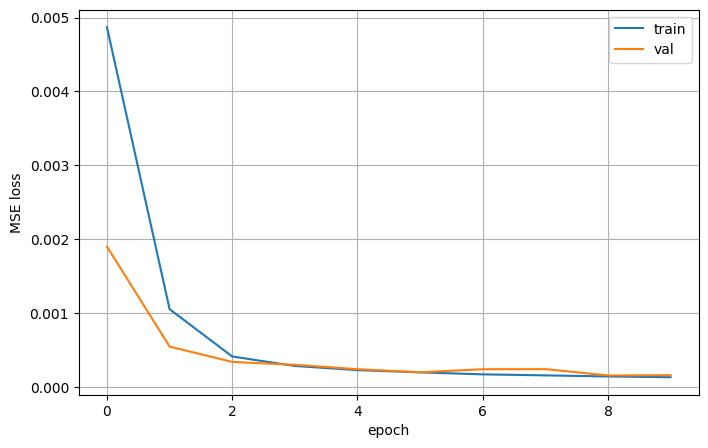

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True)
plt.show()

# Ошибка в пикселях

In [ ]:
def heatmaps_to_points(heatmaps, image_size=128):
    """
    heatmaps: torch.Tensor [B, K, H, W]
    return: torch.Tensor [B, K, 2] в координатах image_size x image_size
    """
    b, k, h, w = heatmaps.shape

    flat = heatmaps.reshape(b, k, -1) # развернула в [B, K, H * W]
    idx = flat.argmax(dim=-1) # позиция, где максимум

    ys = idx // w
    xs = idx % w

    points = torch.stack([xs, ys], dim=-1).float()

    # масштабирую в координаты image_size * image_size
    points[..., 0] *= image_size / w
    points[..., 1] *= image_size / h

    return points

Также здесь в качестве метрики качества я рассмотрела `Normalized Mean Error` - евклидово расстояние между предсказанием и правильной точкой, поделенное на характерный размер лица (расстояние между глазами)

In [ ]:
@torch.no_grad()
def evaluate_landmark_error(model, loader, device, image_size=128):
    model.eval()

    all_pixel_errors = []
    all_nme = []

    for imgs, _, true_points in tqdm(loader, leave=False):
        imgs = imgs.to(device)
        true_points = true_points.to(device)

        pred_heatmaps = model(imgs)[-1]
        pred_points = heatmaps_to_points(pred_heatmaps, image_size=image_size)

        errors = torch.norm(pred_points - true_points, dim=-1)  # [B, 5]
        mean_errors = errors.mean(dim=-1)  # [B]

        # расстояние между глазами
        interocular = torch.norm(true_points[:, 0] - true_points[:, 1], dim=-1)
        nme = mean_errors / (interocular + 1e-6)

        all_pixel_errors.append(mean_errors.cpu())
        all_nme.append(nme.cpu())

    all_pixel_errors = torch.cat(all_pixel_errors)
    all_nme = torch.cat(all_nme)

    return {
        "mean_pixel_error": all_pixel_errors.mean().item(),
        "median_pixel_error": all_pixel_errors.median().item(),
        "mean_nme": all_nme.mean().item(),
        "median_nme": all_nme.median().item(),
    }

In [ ]:
model.load_state_dict(torch.load(OUT_DIR / "stacked_hourglass_best.pt", map_location=device))
metrics = evaluate_landmark_error(model, val_loader, device)
metrics

{'mean_pixel_error': 1.295644760131836,
 'median_pixel_error': 1.0166542530059814,
 'mean_nme': 0.027233997359871864,
 'median_nme': 0.02150787226855755}

# Выравнивание по предсказанным точкам

## Функции выравнивания

In [ ]:
def get_arcface_reference_points(output_size=128):
    """
    стандартные reference-точки ArcFace для размера 112x112,
    масштабированные под output_size
    """
    ref_112 = np.array([
        [38.2946, 51.6963],
        [73.5318, 51.5014],
        [56.0252, 71.7366],
        [41.5493, 92.3655],
        [70.7299, 92.2041],
    ], dtype=np.float32)

    return ref_112 * (output_size / 112.0)

In [ ]:
def align_face_by_points(img_np, src_points, output_size=128):
    """
    img_np - фото в виде массива numpy
    src_points - найденные landmarks
    """
    src_points = np.asarray(src_points, dtype=np.float32)
    dst_points = get_arcface_reference_points(output_size=output_size)

    # ищу матрицу перехода для афинного преобразования
    matrix, _ = cv2.estimateAffinePartial2D(
        src_points,
        dst_points,
        method=cv2.LMEDS,
    )

    if matrix is None:
        return None

    # применяю преобразование
    aligned = cv2.warpAffine(
        img_np,
        matrix,
        (output_size, output_size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )

    return aligned

Тут я решила сделать проверку с правильными landmarks из датасета и убедиться, что все правильно выровнилось:

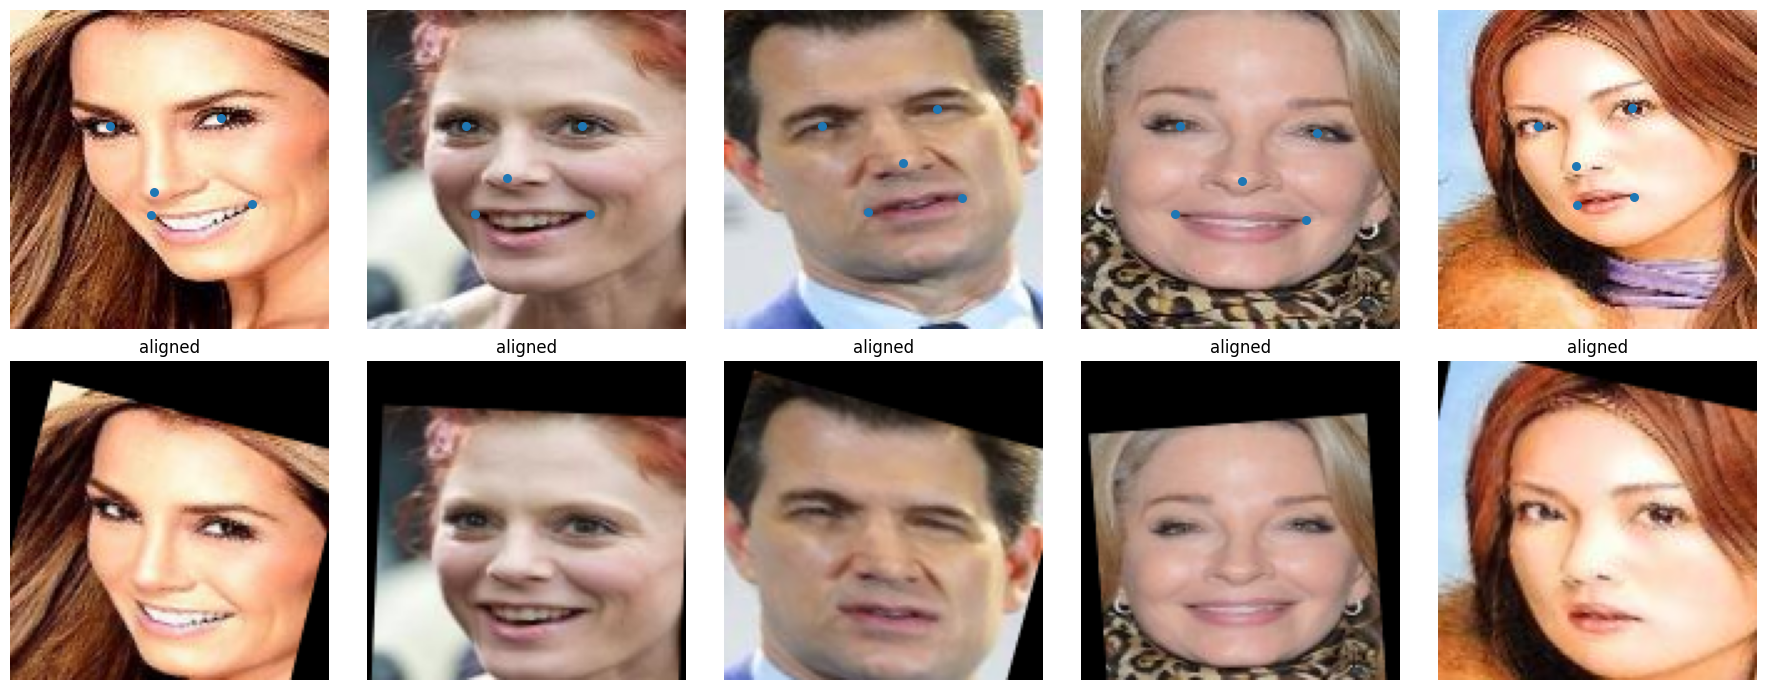

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(18, 7))

for i in range(5):
    row = processed_df.iloc[i]

    img = Image.open(row["crop_path"]).convert("RGB")
    img_np = np.array(img)

    points = row_to_points(row)
    aligned = align_face_by_points(img_np, points, output_size=128)

    axs[0, i].imshow(img_np)
    axs[0, i].scatter(points[:, 0], points[:, 1], s=30)
    axs[0, i].axis("off")

    axs[1, i].imshow(aligned)
    axs[1, i].axis("off")
    axs[1, i].set_title("aligned")

plt.tight_layout()
plt.show()

## Сохранение выровненных лиц

Сначала сохранила выровненные лица для правильных landmarks (ground truth landmarks):

In [ ]:
def save_aligned_ground_truth(processed_df, output_size=128):
    rows = []

    save_dir = ALIGNED_DIR / "gt"
    save_dir.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(processed_df.iterrows(), total=len(processed_df)):
        img = Image.open(row["crop_path"]).convert("RGB")
        img_np = np.array(img)

        points = row_to_points(row)
        aligned = align_face_by_points(img_np, points, output_size=output_size)

        if aligned is None:
            continue

        Image.fromarray(aligned).save(save_dir / row["image_id"])

        new_row = row.copy()
        new_row["aligned_path"] = str(save_dir / row["image_id"])
        rows.append(new_row)

    aligned_df = pd.DataFrame(rows).reset_index(drop=True)
    return aligned_df

In [ ]:
aligned_gt_df = save_aligned_ground_truth(processed_df, output_size=128)
aligned_gt_df.to_csv(OUT_DIR / "aligned_faces_gt.csv", index=False)

aligned_gt_df.shape

100%|██████████| 15017/15017 [00:26<00:00, 577.29it/s]


(15017, 69)

Функция, получающая предсказанные landmarks через обученную модель:

In [ ]:
@torch.no_grad()
def predict_points_for_df(model, df, image_size=128, batch_size=128, device="cuda"):
    tmp_dataset = FaceLandmarksDataset(df, image_size=image_size, heatmap_size=64, sigma=2.0)
    tmp_loader = DataLoader(tmp_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    model.eval()
    all_points = []

    for imgs, _, _ in tqdm(tmp_loader):
        imgs = imgs.to(device)
        pred_heatmaps = model(imgs)[-1]
        pred_points = heatmaps_to_points(pred_heatmaps, image_size=image_size)
        all_points.append(pred_points.cpu().numpy())

    return np.concatenate(all_points, axis=0)

Сохраняю выровненные лица для предсказанных landmarks.

In [ ]:
def save_aligned_by_model(model, processed_df, output_size=128, device="cuda"):
    aligned_dir = ALIGNED_DIR / "pred"
    aligned_dir.mkdir(parents=True, exist_ok=True)

    pred_points_all = predict_points_for_df(
        model,
        processed_df,
        image_size=output_size,
        batch_size=128,
        device=device,
    )

    rows = []

    for idx, row in tqdm(processed_df.iterrows(), total=len(processed_df)):
        img = Image.open(row["crop_path"]).convert("RGB")
        img_np = np.array(img)

        pred_points = pred_points_all[idx]
        aligned = align_face_by_points(img_np, pred_points, output_size=output_size)

        if aligned is None:
            continue

        save_path = aligned_dir / row["image_id"]
        Image.fromarray(aligned).save(save_path)

        new_row = row.copy()
        new_row["aligned_path"] = str(save_path)

        for name, (x, y) in zip(
            ["lefteye", "righteye", "nose", "leftmouth", "rightmouth"],
            pred_points,
        ):
            new_row[f"{name}_x_pred"] = x
            new_row[f"{name}_y_pred"] = y

        rows.append(new_row)

    aligned_df = pd.DataFrame(rows).reset_index(drop=True)
    return aligned_df

In [ ]:
model.load_state_dict(torch.load(OUT_DIR / "stacked_hourglass_best.pt", map_location=device))

<All keys matched successfully>

In [ ]:
aligned_pred_df = save_aligned_by_model(
    model,
    processed_df,
    output_size=128,
    device=device,
)

100%|██████████| 15017/15017 [01:33<00:00, 161.43it/s]


In [ ]:
aligned_pred_df.to_csv(OUT_DIR / "aligned_faces_predicted.csv", index=False)
aligned_pred_df.shape

(15017, 79)

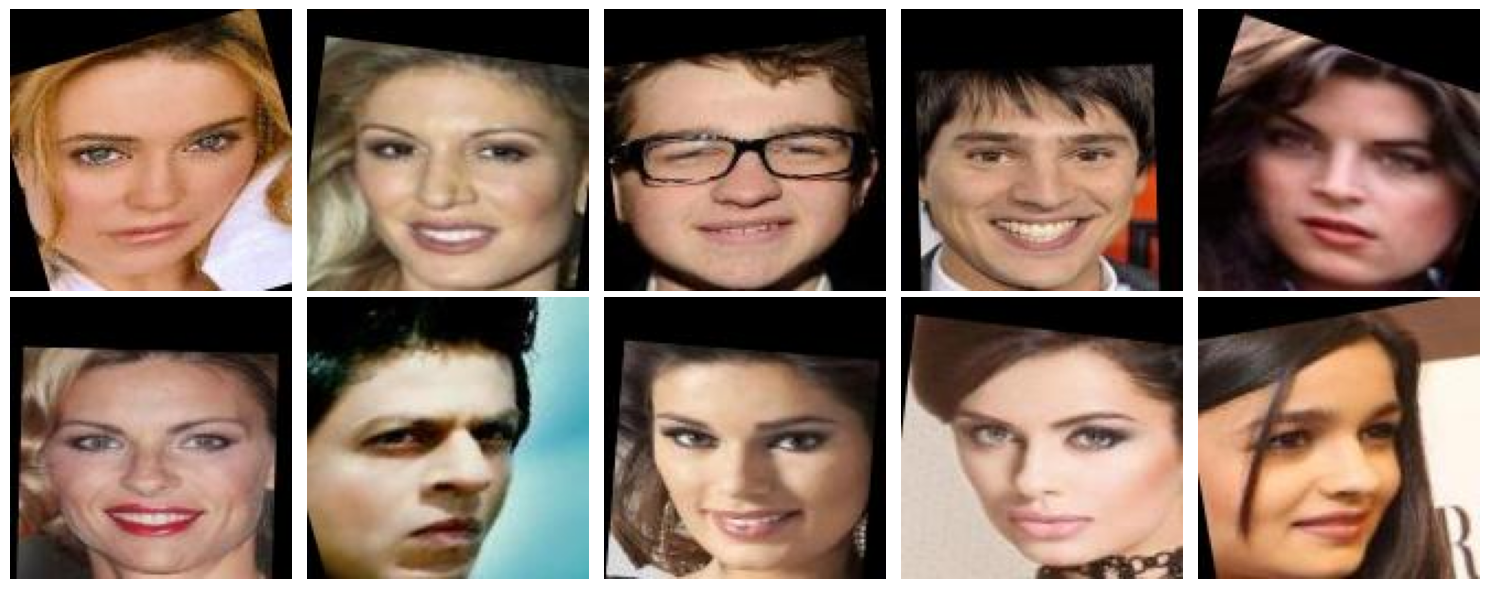

In [ ]:
# визуальная проверка aligned faces
sample_df = aligned_pred_df.sample(10, random_state=42)

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
axs = axs.ravel()

for ax, (_, row) in zip(axs, sample_df.iterrows()):
    img = Image.open(row["aligned_path"]).convert("RGB")
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()
